In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [12]:
df = pd.read_csv("AEP_hourly.csv") 
df.head()


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [13]:
df.columns = ['Datetime', 'Energy']
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

# Night hours only (6 PM to 11 PM)
df = df.between_time('18:00', '23:00')

data = df.values

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [14]:
X = []
y = []

for i in range(24, len(data_scaled)):
    X.append(data_scaled[i-24:i])
    y.append(data_scaled[i])

X, y = np.array(X), np.array(y)


In [15]:
model = Sequential()
model.add(LSTM(50, input_shape=(X.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.fit(X, y, epochs=5, batch_size=32)


c:\Users\MANASVI\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 0.0064
Epoch 2/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.0044
Epoch 3/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 0.0039
Epoch 4/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 49s 51ms/step - loss: 0.0033
Epoch 5/5
947/947 ━━━━━━━━━━━━━━━━━━━━ 93s 61ms/step - loss: 0.0028


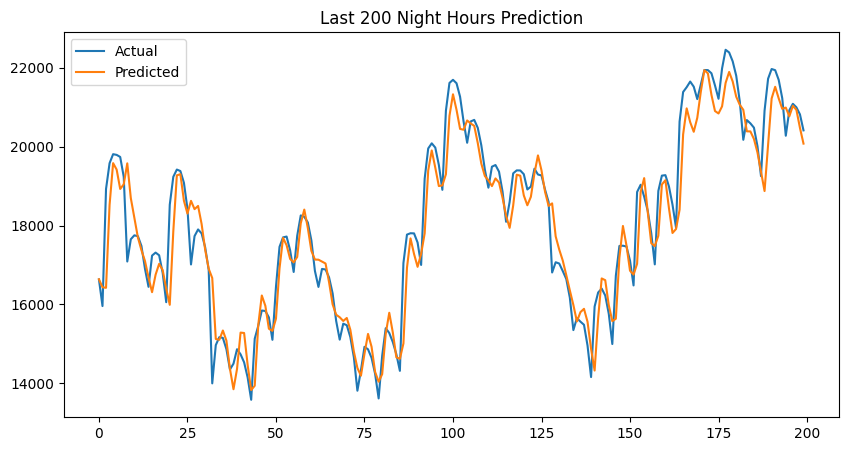

In [16]:


plt.figure(figsize=(10,5))
plt.plot(actual[-200:], label="Actual")
plt.plot(pred[-200:], label="Predicted")
plt.legend()
plt.title("Last 200 Night Hours Prediction")
plt.show()

